# Chaos control and schedule of shuttle buses

A clear, event-driven reimplementation of Nagatani (2006). 

The dimensionless nonlinear map is

$$T_i(m+1)=T_i(m)+\Gamma H_i(m)+\frac{1}{1+S_iH_i(m)},$$

where $H_i(m)$ is measured from the bus that arrived immediately before bus $i$, regardless of bus number. This changing predecessor is the source of the piecewise and chaotic behavior.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from shuttle_model import (
    find_regular_transition,
    simulate,
    summarize,
    theoretical_regular_transition,
    window_observables,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 1. One simulation

The simulator always processes the earliest pending arrival. It therefore handles overtaking directly, without backward searches or mutable “used” flags.

In [12]:
result = simulate(
    initial_times=(1.0, 2.5),
    gamma=0.2,
    speedups=(0.5, 0.2),
    num_trips=2_000,
)

late_stats = summarize(window_observables(result, start=1_000, stop=2_000))
late_stats

{'H1': {'mean': 0.4383221765420234, 'rms': 0.3100897561528495},
 'DT1': {'mean': 0.9209309651072837, 'rms': 0.04186629984708041},
 'H2': {'mean': 0.6225371748458952, 'rms': 0.3376452554863391},
 'DT2': {'mean': 1.0170912879214422, 'rms': 0.01280468297229294}}

## 2. Reusable parameter sweep

Each value of $\Gamma$ is simulated once. Headways, tour times, means, and RMS fluctuations are then reused by all plots.

In [13]:
INITIAL_TIMES = (1.0, 2.5)
NUM_TRIPS = 1_000
BURN_IN = 900


def sweep(gammas, speedups, num_trips=NUM_TRIPS, burn_in=BURN_IN):
    """Simulate a grid and retain late-time observables and summaries."""
    records = []
    for gamma in np.asarray(gammas):
        simulation = simulate(INITIAL_TIMES, gamma, speedups, num_trips)
        values = window_observables(simulation, burn_in, num_trips)
        records.append({
            "gamma": gamma,
            "values": values,
            "stats": summarize(values),
            "diverged": simulation.diverged,
        })
    return records


def scatter_observable(ax, records, name, size=1.0):
    for record in records:
        values = record["values"][name]
        finite = values[np.isfinite(values)]
        ax.scatter(np.full(finite.size, record["gamma"]), finite, s=size, c="black")
    ax.set_xlabel(r"Loading parameter $\Gamma$")
    ax.set_ylabel(name)

## 3. Headway bifurcation diagrams — paper Figs. 2 and 3

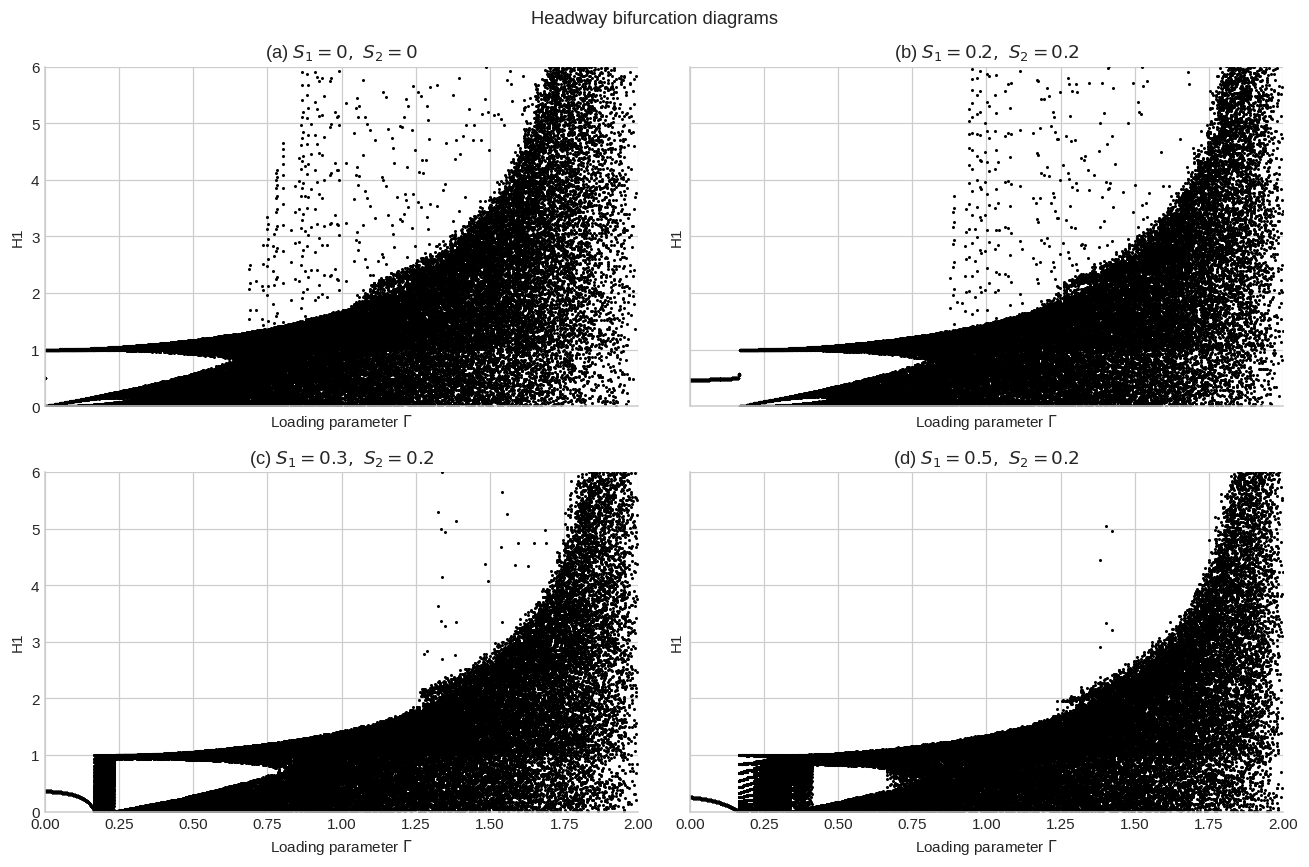

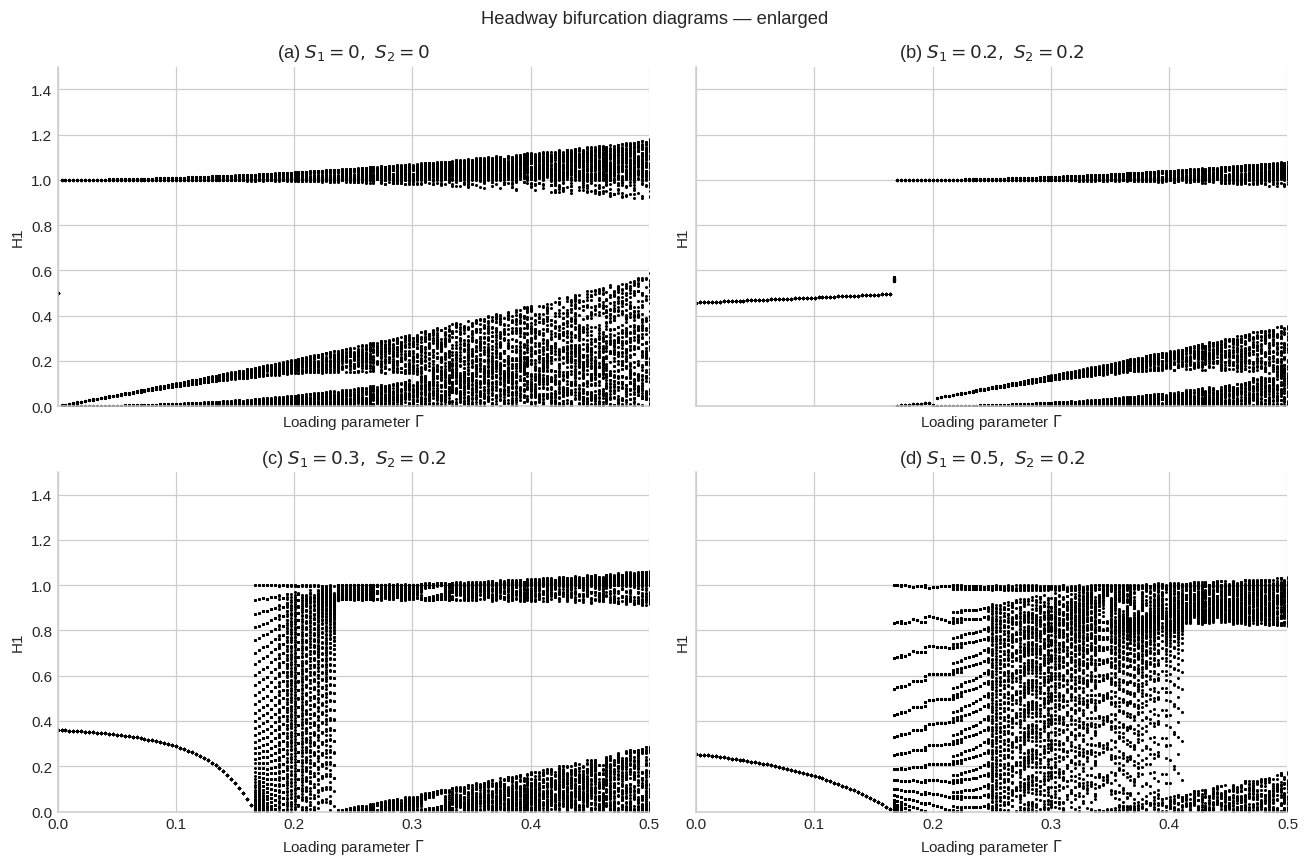

In [14]:
gammas = np.linspace(0.0, 2.0, 600)
configurations = [
    ((0.0, 0.0), r"(a) $S_1=0,\ S_2=0$"),
    ((0.2, 0.2), r"(b) $S_1=0.2,\ S_2=0.2$"),
    ((0.3, 0.2), r"(c) $S_1=0.3,\ S_2=0.2$"),
    ((0.5, 0.2), r"(d) $S_1=0.5,\ S_2=0.2$"),
]
headway_sweeps = {speedups: sweep(gammas, speedups) for speedups, _ in configurations}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, (speedups, title) in zip(axes.flat, configurations):
    scatter_observable(ax, headway_sweeps[speedups], "H1")
    ax.set_title(title)
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 6)
fig.suptitle("Headway bifurcation diagrams")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, (speedups, title) in zip(axes.flat, configurations):
    scatter_observable(ax, headway_sweeps[speedups], "H1")
    ax.set_title(title)
    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 1.5)
fig.suptitle("Headway bifurcation diagrams — enlarged")
fig.tight_layout()
plt.show()

## 4. Tour-time bifurcation diagrams — paper Figs. 4 and 5

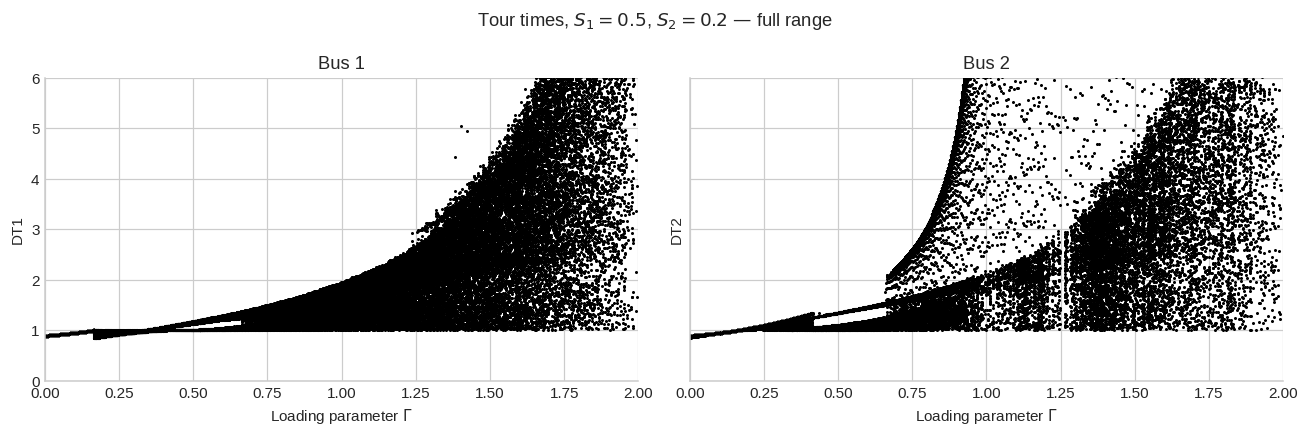

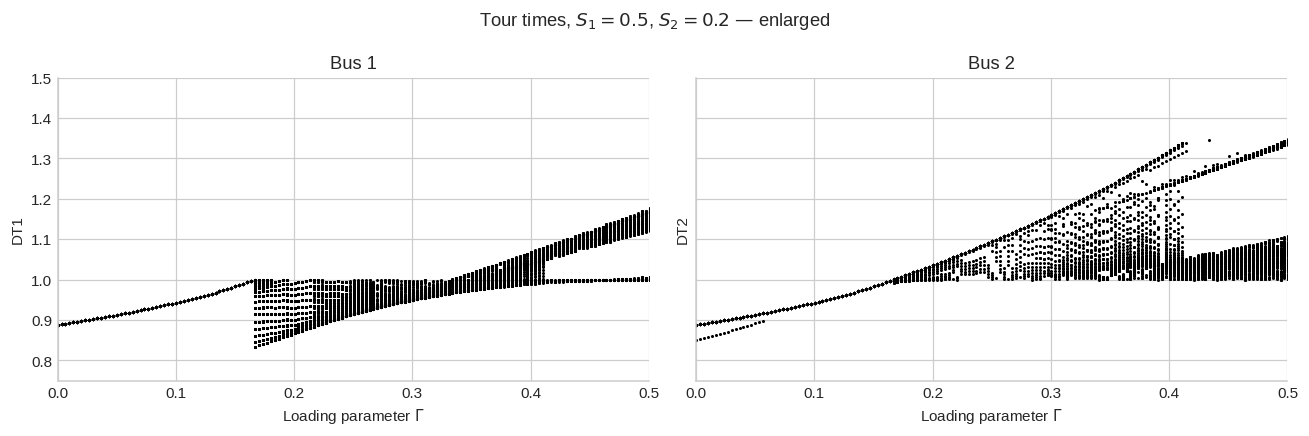

In [15]:
unequal_sweep = headway_sweeps[(0.5, 0.2)]

for xlim, ylim, subtitle in [
    ((0, 2), (0, 6), "full range"),
    ((0, 0.5), (0.75, 1.5), "enlarged"),
]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
    for bus, ax in enumerate(axes, start=1):
        scatter_observable(ax, unequal_sweep, f"DT{bus}")
        ax.set_title(f"Bus {bus}")
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
    fig.suptitle(rf"Tour times, $S_1=0.5$, $S_2=0.2$ — {subtitle}")
    fig.tight_layout()
    plt.show()

## 5. Return maps — paper Fig. 6

The pairs below are successive headways of bus 1: $(H_1(m), H_1(m+1))$. At $\Gamma=0.2$ the 11 distinct points recover the period-11 orbit reported in the paper.

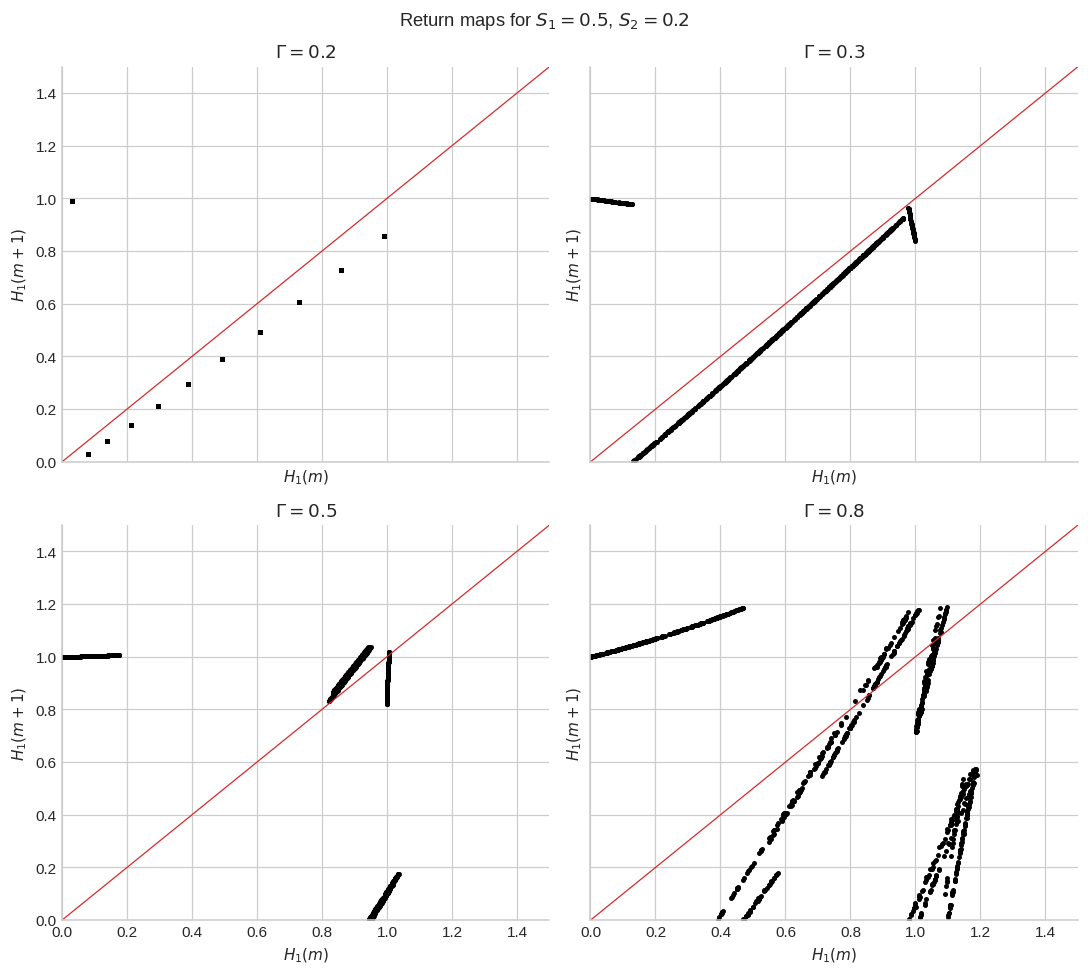

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9), sharex=True, sharey=True)
for ax, gamma in zip(axes.flat, (0.2, 0.3, 0.5, 0.8)):
    simulation = simulate(INITIAL_TIMES, gamma, (0.5, 0.2), num_trips=2_000)
    h1 = simulation.headways_for(0, start=1_000, stop=2_000)
    ax.scatter(h1[:-1], h1[1:], s=5, c="black")
    ax.plot((0, 1.5), (0, 1.5), color="tab:red", linewidth=0.8)
    ax.set_title(rf"$\Gamma={gamma}$")
    ax.set_xlabel(r"$H_1(m)$")
    ax.set_ylabel(r"$H_1(m+1)$")
    ax.set_xlim(0, 1.5)
    ax.set_ylim(0, 1.5)
fig.suptitle(r"Return maps for $S_1=0.5$, $S_2=0.2$")
fig.tight_layout()
plt.show()

## 6. Means and RMS fluctuations — paper Fig. 7

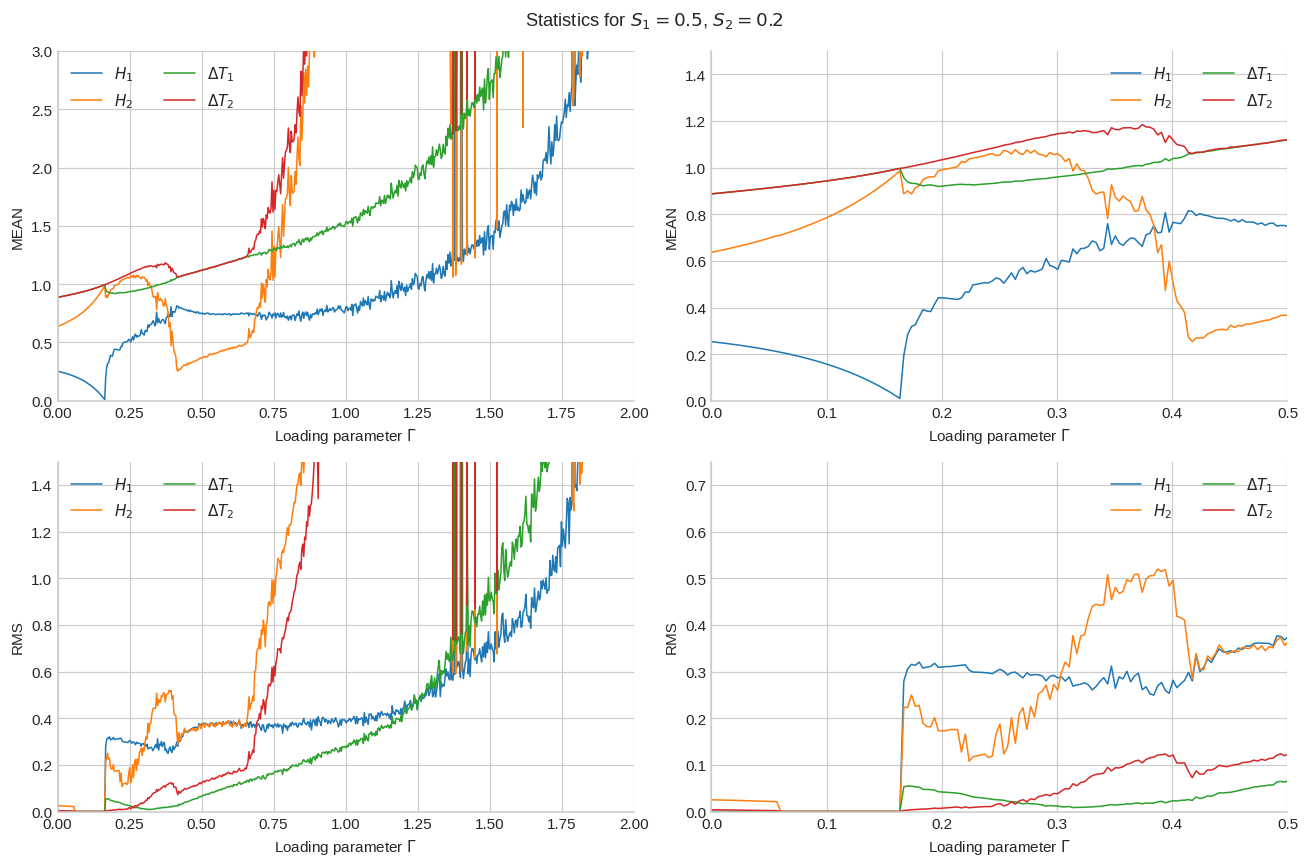

In [17]:
names = ("H1", "H2", "DT1", "DT2")
labels = {"H1": r"$H_1$", "H2": r"$H_2$", "DT1": r"$\Delta T_1$", "DT2": r"$\Delta T_2$"}
gamma_values = np.array([record["gamma"] for record in unequal_sweep])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, metric in enumerate(("mean", "rms")):
    for column, xlim in enumerate(((0, 2), (0, 0.5))):
        ax = axes[row, column]
        for name in names:
            y = np.array([record["stats"][name][metric] for record in unequal_sweep])
            ax.plot(gamma_values, y, linewidth=1, label=labels[name])
        ax.set_xlim(*xlim)
        ax.set_xlabel(r"Loading parameter $\Gamma$")
        ax.set_ylabel(metric.upper())
        ax.legend(ncol=2)
axes[0, 0].set_ylim(0, 3)
axes[0, 1].set_ylim(0, 1.5)
axes[1, 0].set_ylim(0, 1.5)
axes[1, 1].set_ylim(0, 0.75)
fig.suptitle(r"Statistics for $S_1=0.5$, $S_2=0.2$")
fig.tight_layout()
plt.show()

## 7. Phase boundary — paper Fig. 8

For equal speedups, the regular branch has the analytical boundary

$$\Gamma_c=\frac{S}{1+S}.$$

Simulation points use late-time RMS fluctuation and bisection. Near the boundary, convergence is slow, so small numerical offsets are expected for finite runs.

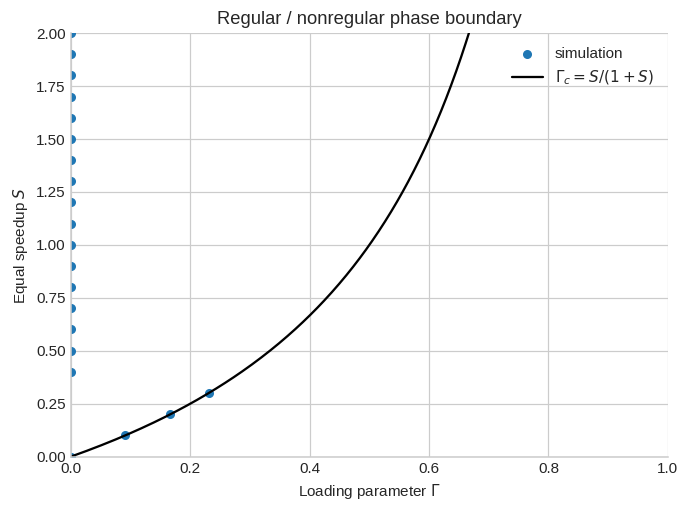

In [18]:
speedup_values = np.linspace(0.0, 2.0, 21)
simulated_boundary = np.array([
    find_regular_transition(
        speedup,
        gamma_max=1.0,
        coarse_points=40,
        bisection_steps=12,
        num_trips=2_000,
        burn_in=1_500,
        tolerance=1e-4,
    )
    for speedup in speedup_values
])

smooth_speedups = np.linspace(0.0, 2.0, 300)
plt.figure(figsize=(7, 5))
plt.scatter(simulated_boundary, speedup_values, s=24, label="simulation")
plt.plot(theoretical_regular_transition(smooth_speedups), smooth_speedups,
         color="black", label=r"$\Gamma_c=S/(1+S)$")
plt.xlabel(r"Loading parameter $\Gamma$")
plt.ylabel(r"Equal speedup $S$")
plt.xlim(0, 1)
plt.ylim(0, 2)
plt.title("Regular / nonregular phase boundary")
plt.legend()
plt.show()

## 8. Ablation study — which assumptions matter?

The reproduction above uses three coupled ingredients from the paper: speed adaptation, bus-specific speedup parameters, and event-driven predecessor selection when buses overtake. This section removes or simplifies those ingredients one at a time and measures the late-time RMS fluctuation

$$\max_X X_{\mathrm{rms}}, \qquad X\in\{H_1,H_2,\Delta T_1,\Delta T_2\}.$$

Small RMS means the buses have settled onto a regular branch; large RMS indicates periodic or chaotic motion after the transient.


Speedup ablation: first sampled nonregular loading
No speedup, S=(0, 0)                 Gamma ~= 0.0033
Equal speedup, S=(0.2, 0.2)          Gamma ~= 0.1669
Unequal speedup, S=(0.5, 0.2)        Gamma ~= 0.1669


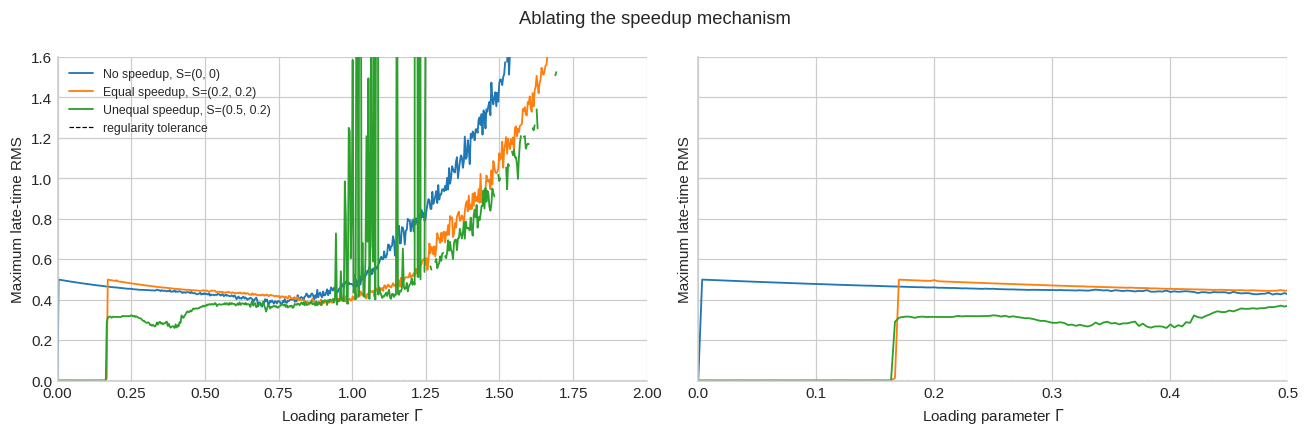

In [19]:
def max_late_rms(record):
    """Return the largest late-time RMS across the four paper observables."""
    if record["diverged"]:
        return np.inf
    rms_values = [record["stats"][name]["rms"] for name in ("H1", "H2", "DT1", "DT2")]
    finite = np.asarray(rms_values, dtype=float)
    finite = finite[np.isfinite(finite)]
    return float(np.max(finite)) if finite.size else np.inf


def first_nonregular_gamma(records, tolerance=1e-4):
    """Locate the first sampled loading value whose late-time RMS is nonzero."""
    for record in records:
        if max_late_rms(record) > tolerance:
            return record["gamma"]
    return np.nan


def sweep_ablation(gammas, speedups, model=simulate, num_trips=1_200, burn_in=900, stop=1_100):
    """Run an ablation sweep with a buffer after the measured late-time window."""
    records = []
    for gamma in np.asarray(gammas):
        simulation = model(INITIAL_TIMES, gamma, speedups, num_trips)
        values = window_observables(simulation, burn_in, stop)
        records.append({
            "gamma": gamma,
            "values": values,
            "stats": summarize(values),
            "diverged": simulation.diverged,
        })
    return records


speedup_ablation = {
    "No speedup, S=(0, 0)": sweep_ablation(gammas, (0.0, 0.0)),
    "Equal speedup, S=(0.2, 0.2)": sweep_ablation(gammas, (0.2, 0.2)),
    "Unequal speedup, S=(0.5, 0.2)": sweep_ablation(gammas, (0.5, 0.2)),
}

print("Speedup ablation: first sampled nonregular loading")
for label, records in speedup_ablation.items():
    transition = first_nonregular_gamma(records)
    print(f"{label:<36} Gamma ~= {transition:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for label, records in speedup_ablation.items():
    x = np.array([record["gamma"] for record in records])
    y = np.array([max_late_rms(record) for record in records])
    y = np.where(np.isfinite(y), y, np.nan)
    axes[0].plot(x, y, linewidth=1.2, label=label)
    axes[1].plot(x, y, linewidth=1.2, label=label)

for ax, xlim in zip(axes, ((0, 2), (0, 0.5))):
    ax.axhline(1e-4, color="black", linestyle="--", linewidth=0.8, label="regularity tolerance")
    ax.set_xlim(*xlim)
    ax.set_xlabel(r"Loading parameter $\Gamma$")
    ax.set_ylabel(r"Maximum late-time RMS")
    ax.set_ylim(0, 1.6)
axes[0].legend(fontsize=8)
fig.suptitle("Ablating the speedup mechanism")
fig.tight_layout()
plt.show()


The speedup ablation separates two effects. Removing speedup leaves the loading feedback mostly unchecked. Equal speedup produces a clean low-$\Gamma$ regular branch, while unequal speedups preserve the same stabilizing mechanism but introduce additional period-adding and chaotic windows.


Predecessor-order ablation: first sampled nonregular loading
Event-driven predecessor     Gamma ~= 0.1676
Fixed cyclic predecessor     Gamma ~= 0.1508


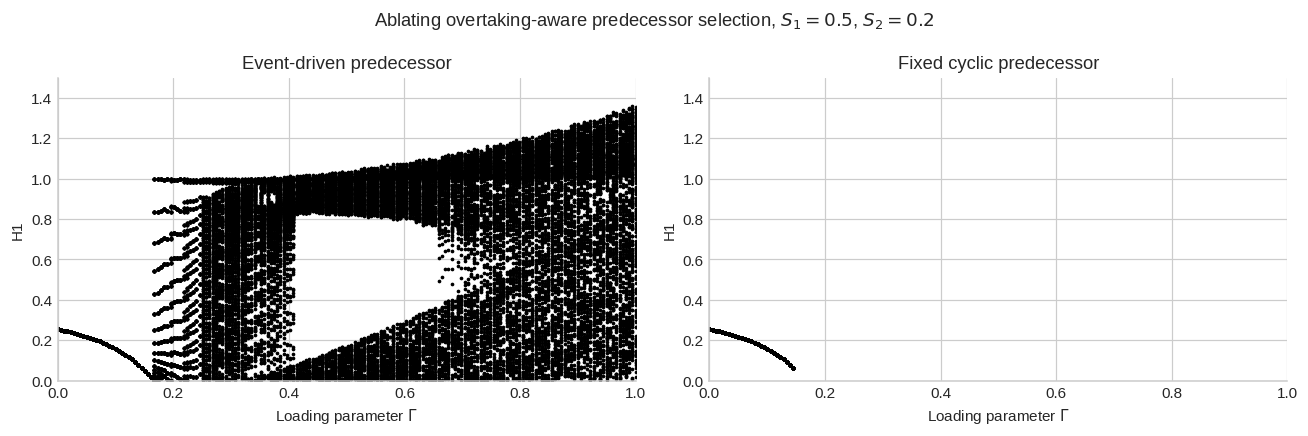

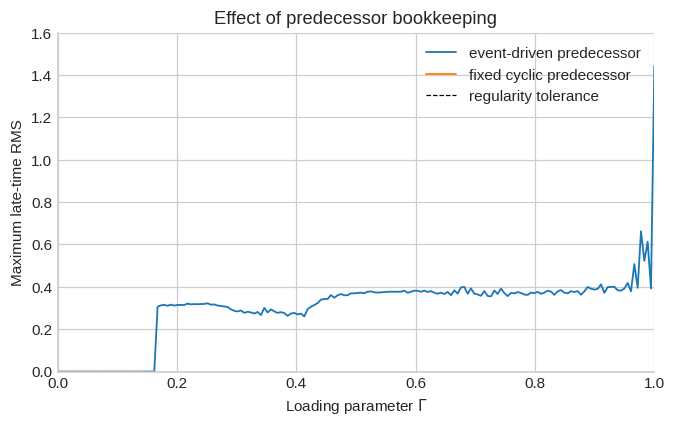

In [20]:
from shuttle_model import SimulationResult


def simulate_fixed_order(
    initial_times=INITIAL_TIMES,
    gamma=0.5,
    speedups=(0.5, 0.2),
    num_trips=NUM_TRIPS,
    *,
    previous_arrival=0.0,
    divergence_limit=1e12,
):
    """Two-bus ablation that keeps a fixed cyclic predecessor order.

    This intentionally removes the event-driven overtaking rule. Bus 1 is always
    treated as following bus 2 from the previous cycle, and bus 2 is always
    treated as following bus 1 from the current cycle.
    """
    initial = np.asarray(tuple(initial_times), dtype=float)
    speed = np.asarray(tuple(speedups), dtype=float)
    if initial.size != 2 or speed.size != 2:
        raise ValueError("fixed-order ablation is defined for the two-bus case")

    arrival_times = np.full((2, num_trips + 1), np.nan, dtype=float)
    headways = np.full_like(arrival_times, np.nan)
    arrival_times[:, 0] = initial
    headways[0, 0] = max(initial[0] - previous_arrival, 0.0)
    headways[1, 0] = max(initial[1] - initial[0], 0.0)
    diverged = False

    for trip in range(num_trips):
        next_times = arrival_times[:, trip] + gamma * headways[:, trip] + 1.0 / (1.0 + speed * headways[:, trip])
        if (not np.all(np.isfinite(next_times))) or np.any(next_times > divergence_limit):
            diverged = True
            break

        arrival_times[:, trip + 1] = next_times
        headways[0, trip + 1] = max(arrival_times[0, trip + 1] - arrival_times[1, trip], 0.0)
        headways[1, trip + 1] = max(arrival_times[1, trip + 1] - arrival_times[0, trip + 1], 0.0)

    return SimulationResult(
        event_times=np.array([], dtype=float),
        event_buses=np.array([], dtype=np.int16),
        event_trips=np.array([], dtype=np.int32),
        arrival_times=arrival_times,
        headways=headways,
        diverged=diverged,
    )


event_order_gammas = np.linspace(0.0, 1.0, 180)
event_driven_records = sweep_ablation(event_order_gammas, (0.5, 0.2), model=simulate)
fixed_order_records = sweep_ablation(event_order_gammas, (0.5, 0.2), model=simulate_fixed_order)

print("Predecessor-order ablation: first sampled nonregular loading")
for label, records in [
    ("Event-driven predecessor", event_driven_records),
    ("Fixed cyclic predecessor", fixed_order_records),
]:
    transition = first_nonregular_gamma(records)
    print(f"{label:<28} Gamma ~= {transition:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, records, title in [
    (axes[0], event_driven_records, "Event-driven predecessor"),
    (axes[1], fixed_order_records, "Fixed cyclic predecessor"),
]:
    scatter_observable(ax, records, "H1", size=2.0)
    ax.set_title(title)
    ax.set_xlim(0, 1.0)
    ax.set_ylim(0, 1.5)
fig.suptitle(r"Ablating overtaking-aware predecessor selection, $S_1=0.5$, $S_2=0.2$")
fig.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
for label, records in [
    ("event-driven predecessor", event_driven_records),
    ("fixed cyclic predecessor", fixed_order_records),
]:
    x = np.array([record["gamma"] for record in records])
    y = np.array([max_late_rms(record) for record in records])
    y = np.where(np.isfinite(y), y, np.nan)
    plt.plot(x, y, linewidth=1.2, label=label)
plt.axhline(1e-4, color="black", linestyle="--", linewidth=0.8, label="regularity tolerance")
plt.xlabel(r"Loading parameter $\Gamma$")
plt.ylabel(r"Maximum late-time RMS")
plt.xlim(0, 1.0)
plt.ylim(0, 1.6)
plt.title("Effect of predecessor bookkeeping")
plt.legend()
plt.show()


The fixed-order variant is not a replacement model; it is a negative control. It keeps the same nonlinear update but removes the global arrival-order rule. Differences between the two panels show that the paper's chaotic windows are not only a consequence of the scalar nonlinearity. They also depend on changing which bus supplies the headway after overtaking.

**Ablation takeaways**

- Speed adaptation is the control mechanism: without it, late-time fluctuations appear almost immediately after $\Gamma=0$.
- Equal speedup gives the cleanest regular boundary, matching the analytical $\Gamma_c=S/(1+S)$ curve.
- Unequal speedup does not simply interpolate between no control and equal control; it introduces richer periodic windows.
- Event-driven predecessor selection is structurally important because it changes the effective map whenever buses overtake.


## Interpretation

- Larger $\Gamma$ strengthens the positive feedback from long headways to loading delay.
- Larger $S_i$ shortens the travel portion of the tour and can suppress that feedback.
- Overtaking changes which arrival supplies the headway, making the effective map piecewise.
- Equal speedup produces a clean regularity boundary; unequal speedups create richer period-adding and chaotic regimes.

See `explaination.md` for the complete derivation and implementation notes.